In [1]:
import pandas as pd

df = pd.read_csv("diabetes_unclean.csv")

df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   str    
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   HbA1c      1006 non-null   float64
 7   Chol       1007 non-null   float64
 8   TG         1007 non-null   float64
 9   HDL        1008 non-null   float64
 10  LDL        1007 non-null   float64
 11  VLDL       1008 non-null   float64
 12  BMI        1009 non-null   float64
 13  CLASS      1009 non-null   str    
dtypes: float64(10), int64(2), str(2)
memory usage: 112.5 KB


In [3]:
df.isnull().sum()

ID           0
No_Pation    0
Gender       0
AGE          1
Urea         1
Cr           2
HbA1c        3
Chol         2
TG           2
HDL          1
LDL          2
VLDL         1
BMI          0
CLASS        0
dtype: int64

In [4]:
df.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='str')

In [5]:
df.drop(["ID", "No_Pation"], axis=1, inplace=True)

In [6]:
df["Gender"].unique()

<ArrowStringArray>
['F', 'M', 'f']
Length: 3, dtype: str

In [7]:
df["Gender"] = df["Gender"].replace({
    "f": "F",
    "m": "M"
})

In [8]:
df["Gender"].unique()

<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str

In [9]:
df.isnull().sum()

Gender    0
AGE       1
Urea      1
Cr        2
HbA1c     3
Chol      2
TG        2
HDL       1
LDL       2
VLDL      1
BMI       0
CLASS     0
dtype: int64

In [14]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

In [16]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [18]:
df.describe()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000
mean,53.620040,5.131094,68.973188,8.284155,4.863873,2.348769,1.204216,2.610119,1.850595,29.589911
std,8.736638,2.929682,59.753929,2.529803,1.296039,1.396100,0.657832,1.114987,3.648048,4.946246
min,25.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


In [13]:
df

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,Gender_M
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N,True
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1004,55.0,NaN,62.0,6.8,5.3,2.0,1.0,3.5,0.9,30.1,Y,True
1005,55.0,4.8,88.0,NaN,5.7,4.0,0.9,3.3,1.8,30.0,Y,True
1006,62.0,6.3,82.0,6.7,5.3,2.0,1.0,3.5,NaN,30.1,Y,True
1007,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y,False


In [19]:
df.head()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,Gender_M
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N,True
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N,True


In [34]:
df["Gender_M"] = df["Gender_M"].astype(int)

In [21]:
df.head()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,Gender_M
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,0
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N,1
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,0
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,0
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N,1


In [38]:
df["CLASS"] = df["CLASS"].astype(str).str.strip()

df["CLASS"] = df["CLASS"].replace({
    "N": 0,
    "Y": 1,
    "P": 1,
    "0": 0,
    "1": 1,
    "nan": 0
})

In [39]:
df["CLASS"] = df["CLASS"].fillna(df["CLASS"].mode()[0])

df["CLASS"] = df["CLASS"].astype(int)

In [40]:
df.head()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,Gender_M
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,1,1
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,1,0
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,1,1


In [41]:
df.isnull().sum()

AGE         0
Urea        0
Cr          0
HbA1c       0
Chol        0
TG          0
HDL         0
LDL         0
VLDL        0
BMI         0
CLASS       0
Gender_M    0
dtype: int64

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
sns.set_style("whitegrid")

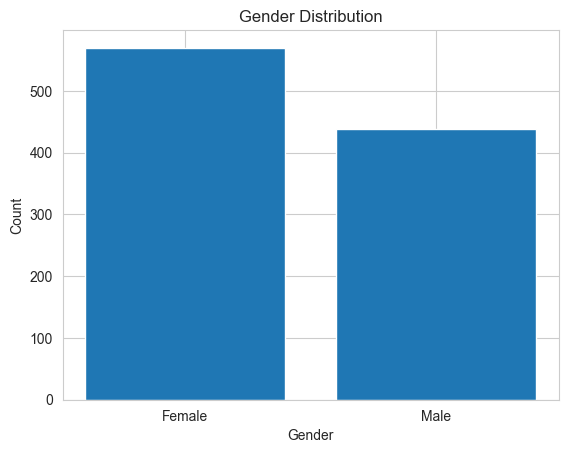

In [44]:
gender_counts = df["Gender_M"].value_counts()

gender_labels = ["Female", "Male"]

plt.bar(gender_labels, gender_counts)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

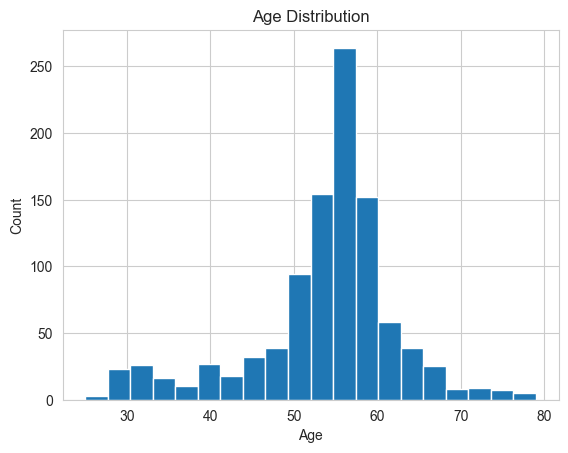

In [45]:
plt.hist(df["AGE"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

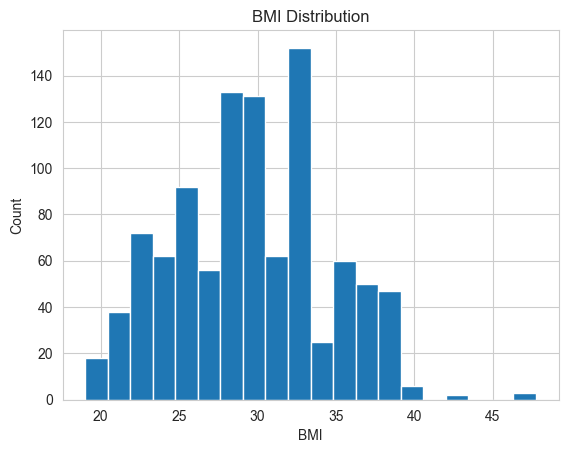

In [46]:
plt.hist(df["BMI"], bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.show()

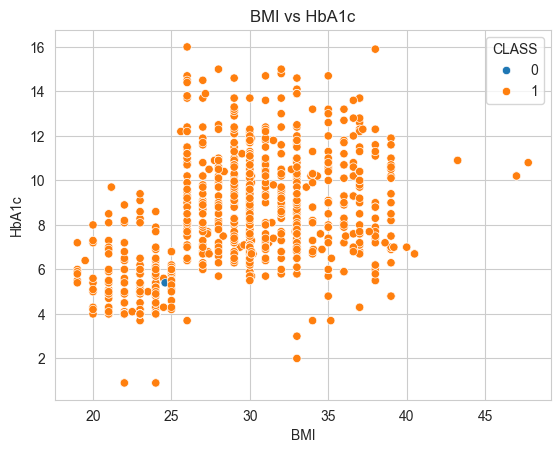

In [47]:
sns.scatterplot(
    x="BMI",
    y="HbA1c",
    hue="CLASS",
    data=df
)

plt.title("BMI vs HbA1c")
plt.show()

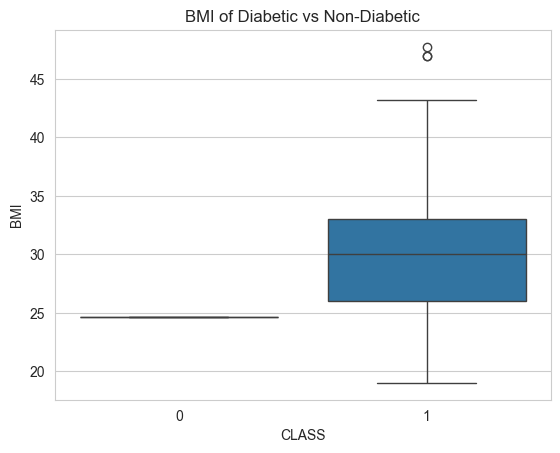

In [48]:
sns.boxplot(
    x="CLASS",
    y="BMI",
    data=df
)

plt.title("BMI of Diabetic vs Non-Diabetic")
plt.show()

In [49]:
X = df.drop("CLASS", axis=1)
y = df["CLASS"]

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [53]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

In [54]:
results = []

In [55]:
for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store Results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [56]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0
2,Decision Tree,1.0,1.0,1.0,1.0
3,Random Forest,1.0,1.0,1.0,1.0
4,KNN,1.0,1.0,1.0,1.0


In [57]:
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0
2,Decision Tree,1.0,1.0,1.0,1.0
3,Random Forest,1.0,1.0,1.0,1.0
4,KNN,1.0,1.0,1.0,1.0


In [58]:
best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [59]:
import joblib

joblib.dump(best_model, "diabetes_model.pkl")

['diabetes_model.pkl']

In [60]:
training_columns = X_train.columns

joblib.dump(training_columns, "training_columns.pkl")

['training_columns.pkl']